# 21_因果推断基础-随机试验：均值差、随机化检验与置信区间

## Notebook 使用说明

建议先阅读《01. 从相关到因果》，再从上到下运行全部单元。需要 NumPy、pandas 和 Matplotlib；正态分位数使用 Python 标准库计算，不需要额外的因果推断软件包。

本篇数据：一个自行构造的 8 人成绩表，以及按参考资料 [1] 第 4.5.1 节生成的潜在结局。分层随机化部分另设教学模拟。数据均在代码中给出，不需要下载文件，也不依赖第一份 Notebook 的变量或 `notebook_support.py`。

本篇主要按 Ding 第 3–5 章的有限总体思路展开：先固定参加试验的人及其潜在结局，再研究随机分组带来的变化。参考资料 [2] 第 2.1 节的总体视角单独作对照，不混用两种方差公式。

代码输出和图形均保存在 Notebook 中。重新运行请使用 **Restart Kernel and Run All Cells**；下文数值解释对应默认参数，修改参数后以新的代码输出为准。书中的 R 模拟改写为 Python，不要求随机结果与原书逐项相同。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
from pathlib import Path
from itertools import combinations
from math import comb
from statistics import NormalDist

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS,
    "axes.unicode_minus": False,
    "figure.dpi": 100,
    "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)

SEED_DATA = 42
SEED_ASSIGN = 2026
SEED_FRT = 2027
SEED_REPEAT = 2028
SEED_PAIRING = 2029
SEED_BLOCK = 2030
ALPHA = 0.05
N_PERMUTATIONS = 4999
N_REPEATS = 4000
Z_CRIT = NormalDist().inv_cdf(1 - ALPHA / 2)

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8


上一篇把同一张潜在结局表反复随机分组，发现两组均值差围绕真实平均效应波动。但现实中通常只有一次试验，不能真的让同一批人重新接受几千次处理。

那只做一次试验，怎么判断结果有没有说服力？比如，辅导组比对照组高了 8.5 分，这个差异会不会只是分组碰巧造成的？如果要报告辅导的平均作用，误差范围又有多大？

这两个问题分别引出随机化检验和置信区间。它们都利用随机分组，但并不是在回答同一个问题。下面先说明随机性来自哪里，再把两种计算各做一遍。

## 理论基础

### 1. 完全随机分配：先定人数，再抽签

假设已经招募了 $n$ 个人，预先确定 $n_1$ 人接受处理、$n_0$ 人进入对照组，且 $n_1+n_0=n$。从所有人中等概率地抽出 $n_1$ 人，这就是完全随机试验（Completely Randomized Experiment，CRE）。[1，第 3.1 节]

可行分组数为：

$$
M=\binom{n}{n_1},\qquad
P(\mathbf T=\mathbf t)=\frac{1}{M},\quad \sum_{i=1}^n t_i=n_1.
$$

比如 8 人中抽 4 人，有 $\binom{8}{4}=70$ 种分法，每种分法的概率都是 $1/70$。代码里只需打乱一个含 4 个 1、4 个 0 的数组。

这与每个人独立抛硬币略有不同：抛硬币时，处理组人数本身也在变化；CRE 的两组人数固定，但具体成员随机。人数固定也意味着各人的 $T_i$ 不互相独立，不能把它们当成独立的伯努利变量。[1，第 3.1 节及脚注]

本篇固定这 $n$ 个人的两个潜在结局，只让分组变化。目标是他们的平均处理效应：

$$
\tau=\operatorname{ATE}_n=\frac{1}{n}\sum_{i=1}^n\{Y_i(1)-Y_i(0)\}.
$$

仍沿用上一篇的 $T$ 表示处理；Ding 书中使用 $Z$。假设处理定义明确、没有个体间干扰，且分配到哪一组就接受对应处理，结局也都能够观察到。

### 2. 两组均值差为什么能估计平均效应？

观察结局仍然是 $Y_i=T_iY_i(1)+(1-T_i)Y_i(0)$。最直接的估计为：

$$
\widehat\tau=\overline Y_{\mathrm{obs},1}-\overline Y_{\mathrm{obs},0}
=\frac{1}{n_1}\sum_i T_iY_i-\frac{1}{n_0}\sum_i(1-T_i)Y_i.
$$

因为处理组中的 $Y_i$ 就是 $Y_i(1)$，而每个人进入处理组的概率均为 $n_1/n$，所以：

$$
E_T\!\left[\frac{1}{n_1}\sum_i T_iY_i(1)\right]
=\frac{1}{n_1}\sum_i\frac{n_1}{n}Y_i(1)
=\frac{1}{n}\sum_iY_i(1).
$$

对照组也一样。两式相减，得到 $E_T[\widehat\tau]=\tau$，即均值差是无偏估计。[1，定理 4.1、第 4.3 节]

下标 $T$ 提醒我们：这里的平均是对所有可能分组取平均，不是重新招募受试者。无偏不等于每次都算对；一次试验仍可能恰好把基础较好的人多分到某一组。

### 3. “没有效应”其实有两种说法

Fisher 的尖锐零假设（sharp null）要求每个人都没有效应：

$$
H_{0F}:Y_i(1)=Y_i(0),\qquad \text{对所有 }i.
$$

它很强，但也因此能够补全反事实：既然两种状态相同，每个人未观察到的结局就等于他已经观察到的结局。无论怎样重新分组，$\mathbf Y$ 都不变，只需改变 $\mathbf T$。这就是 Fisher 随机化检验（FRT）的出发点。[1，第 3.2 节]

Neyman 的弱零假设只要求平均效应为零：

$$
H_{0N}:\tau=0.
$$

例如两个人的效应分别是 $-3$ 和 $+3$，平均为零，却不能说每个人都没有效应。因此，$H_{0F}$ 成立必然有 $H_{0N}$ 成立，反过来不成立。[1，第 4.2 节]

| 比较内容 | Fisher 随机化检验 | Neyman 平均效应推断 |
|---|---|---|
| 本篇回答的问题 | 数据是否与“每个人都无效”相容？ | 平均效应是多少，估计有多大波动？ |
| 核心做法 | 在尖锐零假设下重放原分组机制 | 研究均值差的抽样方差，构造区间 |
| 是否要求人人效应相同 | 零假设规定人人效应都为 0 | 不要求 |
| 本篇使用的保证 | 正确随机化机制下的有限样本有效检验 | 满足条件时的大样本近似区间 |

因此，不能把后面基于普通均值差的 FRT 直接称为“平均效应等于零的精确检验”。针对弱零假设的学生化随机化检验，原书第 8 章另有讨论，本篇不展开。

### 4. 标准误与置信区间怎么算？

先把“人和人之间有多大差异”与“估计量有多大波动”分开。完整表中两项潜在结局的方差，记为：

$$
S_t^2=\frac{1}{n-1}\sum_i\{Y_i(t)-\overline Y(t)\}^2,\quad t\in\{0,1\}.
$$

个体效应 $\tau_i=Y_i(1)-Y_i(0)$ 的方差记为 $S_\tau^2$。CRE 下，均值差的真实方差是：

$$
\operatorname{Var}_T(\widehat\tau)
=\frac{S_1^2}{n_1}+\frac{S_0^2}{n_0}-\frac{S_\tau^2}{n}.
$$

这是 Neyman 的方差公式。[1，定理 4.1] 前两项涉及两种潜在结局各自的变异，最后一项涉及同一个人的两项结局如何配对。现实中无法同时观察它们，也就不能直接计算 $S_\tau^2$。

实际计算时，用处理组、对照组中观察结局的样本方差 $s_1^2,s_0^2$ 代替前两项，并去掉无法观察的最后一项：

$$
\widehat V=\frac{s_1^2}{n_1}+\frac{s_0^2}{n_0},\qquad
\widehat{\operatorname{SE}}=\sqrt{\widehat V}.
$$

所有样本方差都用“人数减一”作分母，在 NumPy 中对应 `ddof=1`。这里的保守性是指：

$$
E_T[\widehat V]-\operatorname{Var}_T(\widehat\tau)=\frac{S_\tau^2}{n}\geq 0.
$$

也就是方差估计平均偏大，不是每一次算出的 $\widehat V$ 都一定大于真实方差。当每人的效应相同，$S_\tau^2=0$，这个差额消失。

在两组人数足够、没有少数极端结局支配波动等条件下，用正态近似构造 95% 置信区间：

$$
\widehat\tau\ \pm\ z_{0.975}\widehat{\operatorname{SE}},\qquad z_{0.975}\approx1.96.
$$

“95%”描述反复按同一设计做试验时，区间覆盖固定真值的长期比例。它不是对某个已算好区间的后验概率，也不是 95% 个体效应所在的范围。这里使用的是大样本近似，并不保证任意小样本都恰好有 95% 覆盖率。[1，定理 4.2]

## 完整案例一：把所有分组列出来

### 1. 一次 8 人试验

先看一个人为构造的成绩表。假定 8 名学生被完全随机分为两组，每组 4 人，$T=1$ 表示参加同一项辅导。表里的数字只是用于计算，不是真实研究数据。为便于阅读，把处理组的记录排在前面，行顺序不代表分配规则。

这次辅导组的平均成绩较高。我们先计算差了多少，再检验“每个人参加与不参加辅导都没有差别”这个假设。

In [2]:
small_observed = pd.DataFrame({
    "学生": list("ABCDEFGH"),
    "T": [1, 1, 1, 1, 0, 0, 0, 0],
    "Y": [70.0, 72.0, 74.0, 80.0, 60.0, 64.0, 68.0, 70.0],
})
t_small = small_observed["T"].to_numpy()
y_small = small_observed["Y"].to_numpy()
display(small_observed)
display(small_observed.groupby("T")["Y"].agg(人数="size", 平均成绩="mean"))

,学生,T,Y
0,A,1,70.0
1,B,1,72.0
2,C,1,74.0
3,D,1,80.0
4,E,0,60.0
5,F,0,64.0
6,G,0,68.0
7,H,0,70.0


,人数,平均成绩
T,,
0,4,65.5
1,4,74.0


In [3]:
def checked_groups(t: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """检查观察数据，并按处理状态返回两组结局。"""
    t = np.asarray(t)
    y = np.asarray(y, dtype=float)
    if t.ndim != 1 or y.ndim != 1 or len(t) != len(y):
        raise ValueError("T 和 Y 必须是一维、等长的数组。")
    if not np.isin(t, [0, 1]).all() or not np.isfinite(y).all():
        raise ValueError("T 只能取 0/1，Y 必须是有限数值。")
    treated, control = y[t == 1], y[t == 0]
    if len(treated) == 0 or len(control) == 0:
        raise ValueError("处理组和对照组都必须有人。")
    return treated, control


def difference_in_means(t: np.ndarray, y: np.ndarray) -> float:
    """计算处理组均值减去对照组均值；不使用潜在结局真值。"""
    treated, control = checked_groups(t, y)
    return float(treated.mean() - control.mean())


small_stat = difference_in_means(t_small, y_small)
print(f"这次试验的观察均值差：{small_stat:.2f} 分")

这次试验的观察均值差：8.50 分


### 2. 固定成绩，枚举 70 种分配

在 $H_{0F}$ 下，学生 A 不管分到哪一组，成绩都还是 70 分，B 都还是 72 分，依此类推。我们便可以固定整列 `Y`，枚举“哪 4 人接受处理”，每种分法都计算一次均值差。

注意，是 70 种处理分配等可能，并不是每个不同的均值差等可能。同一个均值差可能由好几种分组产生。[1，第 3.2 节]

In [4]:
n_small = len(y_small)
n1_small = int(t_small.sum())
assignment_rows = []

# combinations 给出每一种处理组成员集合，不重复排列组内顺序。
for treated_ids in combinations(range(n_small), n1_small):
    assignment = np.zeros(n_small, dtype=int)
    assignment[list(treated_ids)] = 1
    assignment_rows.append(assignment)

all_assignments = np.asarray(assignment_rows)
exact_stats = np.array([
    difference_in_means(assignment, y_small)
    for assignment in all_assignments
])
assignment_preview = pd.DataFrame(all_assignments, columns=small_observed["学生"])
assignment_preview["均值差"] = exact_stats

display(assignment_preview.head(10))
print(f"共有 {len(all_assignments)} 种分配，理论值为 C(8, 4) = {comb(8, 4)}。")
assert len(all_assignments) == comb(n_small, n1_small)
assert np.all(all_assignments.sum(axis=1) == n1_small)
assert len(np.unique(all_assignments, axis=0)) == len(all_assignments)

学生,A,B,C,D,E,F,G,H,均值差
0,1,1,1,1,0,0,0,0,8.5
1,1,1,1,0,1,0,0,0,-1.5
2,1,1,1,0,0,1,0,0,0.5
3,1,1,1,0,0,0,1,0,2.5
4,1,1,1,0,0,0,0,1,3.5
5,1,1,0,1,1,0,0,0,1.5
6,1,1,0,1,0,1,0,0,3.5
7,1,1,0,1,0,0,1,0,5.5
8,1,1,0,1,0,0,0,1,6.5
9,1,1,0,0,1,1,0,0,-6.5


共有 70 种分配，理论值为 C(8, 4) = 70。


### 3. 计算双侧 p 值

本篇预先采用双侧比较：无论均值差过大还是过小，都视为偏离“人人无效”的证据。以绝对均值差为统计量，精确 p 值为：

$$
p_{\mathrm{exact}}
=\frac{\#\{m:|\widehat\tau^{(m)}|\geq|\widehat\tau_{\mathrm{obs}}|\}}{M}.
$$

“至少同样极端”包含相等的情况。由于已枚举全部分配，原来的分组也在其中，分母直接用 $M$。[1，第 3.2 节及双侧检验脚注]

In [5]:
# 很小的容差只用于避免浮点舍入把理论上相等的统计量漏掉。
tol = 1e-12
extreme = np.abs(exact_stats) >= abs(small_stat) - tol
p_exact = float(extreme.mean())

print(f"观察均值差：{small_stat:.2f} 分")
print(f"至少同样极端的分配：{extreme.sum()} / {len(exact_stats)}")
print(f"双侧精确 p 值：{p_exact:.6f}")
print(f"按 alpha={ALPHA:.2f}，是否拒绝尖锐零假设：{p_exact <= ALPHA}")

# 作为数值核对：固定 Y 的零假设随机化分布，均值应为 0。
np.testing.assert_allclose(exact_stats.mean(), 0, atol=1e-12)
null_variance = n_small * y_small.var(ddof=1) / (n1_small * (n_small - n1_small))
np.testing.assert_allclose(exact_stats.var(ddof=0), null_variance, atol=1e-12)

观察均值差：8.50 分
至少同样极端的分配：4 / 70
双侧精确 p 值：0.057143
按 alpha=0.05，是否拒绝尖锐零假设：False


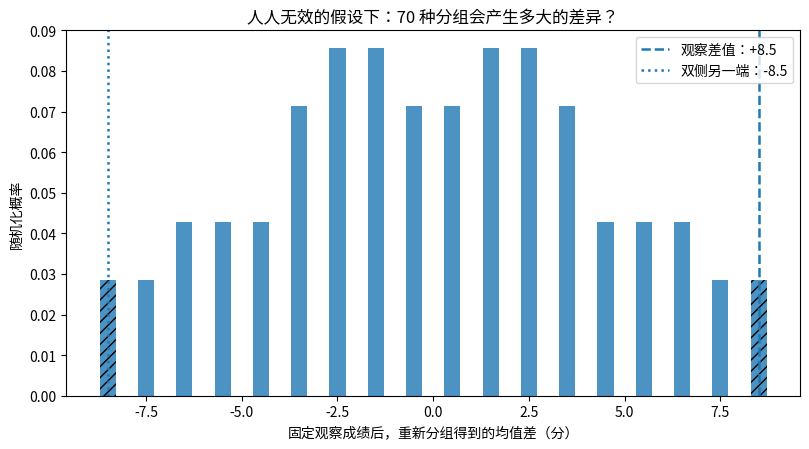

In [6]:
# 按取值统计频数；不是把每个不同的均值差都赋予相同概率。
values, counts = np.unique(exact_stats, return_counts=True)
fig, ax = plt.subplots(figsize=(8.2, 4.6))
bars = ax.bar(values, counts / len(exact_stats), width=0.42, alpha=0.8)
for bar, value in zip(bars, values):
    if abs(value) >= abs(small_stat) - tol:
        bar.set_hatch("///")
ax.axvline(small_stat, linestyle="--", linewidth=1.8, label=f"观察差值：+{small_stat:.1f}")
ax.axvline(-small_stat, linestyle=":", linewidth=1.8, label=f"双侧另一端：-{small_stat:.1f}")
ax.set_xlabel("固定观察成绩后，重新分组得到的均值差（分）")
ax.set_ylabel("随机化概率")
ax.set_title("人人无效的假设下：70 种分组会产生多大的差异？")
ax.legend()
fig.tight_layout()
plt.show()

图中斜线柱对应至少同样极端的分组，一共有 4 种，所以 p 值是 $4/70\approx0.0571$。在预先取定的 0.05 水平下，这个例子没有拒绝尖锐零假设。

这不表示“有 5.71% 的概率辅导无效”，也不等于证明辅导无效。它说的是：假定每个人都无效，按原来的抽签规则重新分配，出现至少这么大绝对差异的概率约为 5.71%。小样本能提供的证据有其限制。

### 4. 分组太多时，用随机抽取近似

100 人中选 60 人，就很难再枚举全部分配。可以独立地随机抽取 $B$ 次分组，记录其中 $K$ 次至少同样极端。这里按 Ding 习题 3.3 使用：

$$
p_{\mathrm{MC}}=\frac{K+1}{B+1}.
$$

这个加一形式让有限次 Monte Carlo 计算也给出有效 p 值，且不会因恰好没抽到极端分配而报告 p=0。[1，习题 3.3] 它只用于这种随机抽取的检验；前面的完整枚举不需要加一。

先仍在 8 人数据上比较，这样我们知道精确答案，能够直接看到近似误差。

In [7]:
def fisher_mc(t: np.ndarray, y: np.ndarray, n_draws: int, seed: int) -> dict:
    """CRE 下，以绝对均值差为统计量的双侧 Fisher 随机化检验。"""
    checked_groups(t, y)
    if not isinstance(n_draws, (int, np.integer)) or n_draws < 1:
        raise ValueError("n_draws 必须是正整数。")
    t = np.asarray(t, dtype=int)
    y = np.asarray(y, dtype=float)
    rng = np.random.default_rng(seed)
    observed_stat = difference_in_means(t, y)
    perm_stats = np.empty(n_draws)
    for b in range(n_draws):
        # 每次独立地打乱原始标签，保留组人数；Y 始终不变。
        perm_stats[b] = difference_in_means(rng.permutation(t), y)
    tolerance = 1e-12 * max(1.0, abs(observed_stat))
    k = int(np.sum(np.abs(perm_stats) >= abs(observed_stat) - tolerance))
    return {
        "statistic": observed_stat, "extreme_count": k,
        "n_draws": n_draws, "p_value": (k + 1) / (n_draws + 1),
        "randomization_stats": perm_stats,
    }


small_mc = fisher_mc(t_small, y_small, N_PERMUTATIONS, SEED_FRT)
display(pd.Series({
    "完整枚举 p 值": p_exact,
    "Monte Carlo p 值": small_mc["p_value"],
    "两者之差": small_mc["p_value"] - p_exact,
    "随机抽取次数": N_PERMUTATIONS,
    "本次 MC 检验可报告的最小 p 值": 1 / (N_PERMUTATIONS + 1),
}).to_frame("结果"))
assert 0 < small_mc["p_value"] <= 1

,结果
完整枚举 p 值,0.057143
Monte Carlo p 值,0.055000
两者之差,-0.002143
随机抽取次数,4999.000000
本次 MC 检验可报告的最小 p 值,0.000200


精确检验与 Monte Carlo 检验使用同一个零假设、同一个统计量和同一个分配机制；区别在于是否检查了全部分组。增加抽取次数会减少计算近似的误差，却不会增加试验的真实受试者，也不会使效应估计的标准误变小。

## 完整案例二：一次试验的效应和误差范围

### 1. 生成潜在结局，再随机分组

采用 Ding 第 4.5.1 节的模拟：100 人中固定 60 人接受处理、40 人进入对照组，先生成 $Y_i(0)\sim\operatorname{Exp}(1)$，再设：

$$
Y_i(1)=Y_i(0)+1.
$$

这里结局没有指定实际单位。指数分布让结局右偏，便于说明“结局本身服从正态分布”不是随机化推断的起点。模拟完整表的每个人都恰好增加 1，所以这 100 人的真实平均效应也是 1。

先生成完整表，之后不再重新抽取这些人。分析函数只接收观察到的 `T` 和 `Y`，潜在结局保留在另一个对象中用于核对。

In [8]:
n, n1 = 100, 60
n0 = n - n1
rng_data = np.random.default_rng(SEED_DATA)
y0 = np.sort(rng_data.exponential(scale=1.0, size=n))[::-1]
y1 = y0 + 1.0
truth = pd.DataFrame({"Y0": y0, "Y1": y1, "tau": y1 - y0})
true_ate = float(truth["tau"].mean())

assignment_template = np.r_[np.ones(n1, dtype=int), np.zeros(n0, dtype=int)]
rng_assign = np.random.default_rng(SEED_ASSIGN)
t = rng_assign.permutation(assignment_template)
y = np.where(t == 1, y1, y0)
observed = pd.DataFrame({"编号": np.arange(1, n + 1), "T": t, "Y": y})

display(observed.head(8))
display(observed.groupby("T")["Y"].agg(人数="size", 均值="mean", 样本方差="var").round(4))
print(f"模拟完整表的真实 ATE：{true_ate:.4f}")
assert int(t.sum()) == n1
np.testing.assert_allclose(truth["tau"], 1.0)

,编号,T,Y
0,1,1,6.309883
1,2,1,4.995756
2,3,0,3.124296
3,4,1,3.553419
4,5,0,2.404209
5,6,1,3.384761
6,7,1,3.336190
7,8,0,2.251879


,人数,均值,样本方差
T,,,
0,40,0.8041,0.601
1,60,1.9624,0.920


模拟完整表的真实 ATE：1.0000


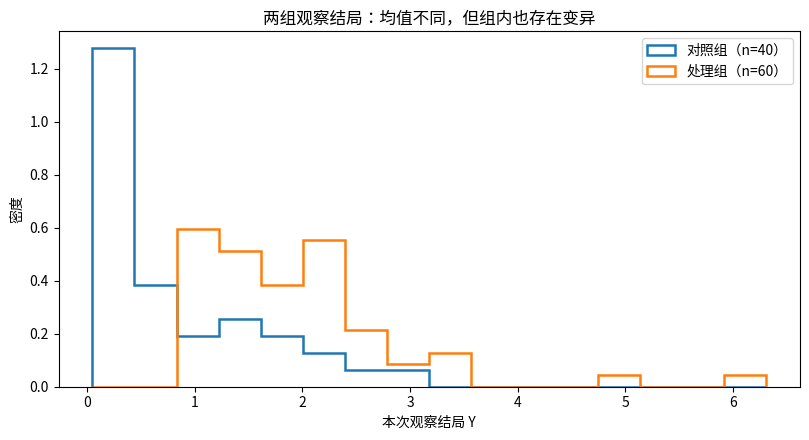

In [9]:
fig, ax = plt.subplots(figsize=(8.2, 4.5))
bins = np.linspace(y.min(), y.max(), 17)
for group, label in [(0, "对照组"), (1, "处理组")]:
    ax.hist(y[t == group], bins=bins, density=True, histtype="step", linewidth=1.8,
            label=f"{label}（n={int((t == group).sum())}）")
ax.set_xlabel("本次观察结局 Y")
ax.set_ylabel("密度")
ax.set_title("两组观察结局：均值不同，但组内也存在变异")
ax.legend()
fig.tight_layout()
plt.show()

### 2. 先按公式逐步计算

先不封装函数，把均值差、两组样本方差、方差估计、标准误和区间上下限依次列出来。这里不把方差除以总人数，也不再对标准误除一次 $\sqrt n$：$s_1^2/n_1+s_0^2/n_0$ 已经是均值差的方差估计。

In [10]:
y_treated, y_control = y[t == 1], y[t == 0]
tau_hat = float(y_treated.mean() - y_control.mean())
s1_sq = float(y_treated.var(ddof=1))
s0_sq = float(y_control.var(ddof=1))
v_hat = s1_sq / n1 + s0_sq / n0
se_hat = np.sqrt(v_hat)
ci_low = tau_hat - Z_CRIT * se_hat
ci_high = tau_hat + Z_CRIT * se_hat

single_result = pd.Series({
    "均值差估计": tau_hat,
    "处理组样本方差 s1²": s1_sq,
    "对照组样本方差 s0²": s0_sq,
    "Neyman 方差估计": v_hat,
    "估计标准误": se_hat,
    "95% 区间下限": ci_low,
    "95% 区间上限": ci_high,
    "模拟真实 ATE": true_ate,
})
display(single_result.round(4).to_frame("结果"))

,结果
均值差估计,1.1583
处理组样本方差 s1²,0.9200
对照组样本方差 s0²,0.6010
Neyman 方差估计,0.0304
估计标准误,0.1742
95% 区间下限,0.8168
95% 区间上限,1.4998
模拟真实 ATE,1.0000


默认输出中，均值差约为 1.1583，标准误约为 0.1742，95% 区间约为 [0.8168, 1.4998]，覆盖了这张完整表的真实效应 1。

这里的区间是平均效应的误差范围，不是处理组结局的范围。模拟真值只用于检查，不能放进真实数据的估计步骤。

还可以对同一份观察数据做 FRT。但它的重抽过程仍然固定 `y`，在“每个人都无效”的假设下打乱标签；不能在这个检验中偷用 `y0` 和 `y1`。

In [11]:
main_frt = fisher_mc(t, y, N_PERMUTATIONS, SEED_FRT + 1)
print(f"FRT 的观察统计量：{main_frt['statistic']:.4f}")
print(f"随机抽取 {main_frt['n_draws']} 次，至少同样极端 {main_frt['extreme_count']} 次。")
print(f"FRT 双侧 Monte Carlo p 值：{main_frt['p_value']:.6f}")
print(f"Neyman 95% 区间：[{ci_low:.4f}, {ci_high:.4f}]")
print(f"区间是否包含 0：{ci_low <= 0 <= ci_high}")
np.testing.assert_allclose(main_frt["statistic"], tau_hat)

FRT 的观察统计量：1.1583
随机抽取 4999 次，至少同样极端 0 次。
FRT 双侧 Monte Carlo p 值：0.000200
Neyman 95% 区间：[0.8168, 1.4998]
区间是否包含 0：False


这次抽取的 4,999 种分配中，没有出现至少同样极端的差异，加一修正给出 p=0.0002。这不是说精确 p 值恰好等于 0.0002，而是当前随机抽取次数下的检验结果；需要更细的数值分辨率时，应增加抽取次数，不能把 0 次直接写成 p=0。

两项输出应分别解释：FRT 在检查尖锐零假设，区间则在描述平均效应的不确定性。它们不需要在所有数据上作出完全相同的判断。尤其有异质性效应时，“人人都无效”和“平均为零”不能互换。

### 3. 把重复用到的计算封装起来

下面的函数只从两组观察结局计算点估计与方差。把它与刚才展开的计算核对后，再用于重复试验。[1，第 4.2 节]

In [12]:
def neyman_estimate(t: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    """返回 CRE 下的均值差及 Neyman 方差估计。"""
    treated, control = checked_groups(t, y)
    if min(len(treated), len(control)) < 2:
        raise ValueError("计算组内样本方差时，每组至少需要 2 人。")
    estimate = float(treated.mean() - control.mean())
    variance = float(treated.var(ddof=1) / len(treated)
                     + control.var(ddof=1) / len(control))
    return estimate, variance


np.testing.assert_allclose(neyman_estimate(t, y), [tau_hat, v_hat])
print("函数结果与逐步计算一致。")

函数结果与逐步计算一致。


### 4. 固定完整表，重复做 4,000 次试验

现在换一个任务：不是模拟零假设，而是检查估计方法在这张已知完整表上的表现。

每次都重新分组，然后用新的处理状态重新生成观察结局。有人从处理组变成对照组，他的结局就从 $Y_i(1)$ 变成 $Y_i(0)$。这与 FRT 中固定观察成绩的做法不同。[1，第 4.2 节，图 4.1 与图 3.1 的比较]

每次生成的数据都独立算一个均值差和一个区间。我们关心平均估计是否接近真值、估计值的实际波动多大，以及区间覆盖真值的比例。

In [13]:
def simulate_cre(y0: np.ndarray, y1: np.ndarray, n1: int,
                 n_repeats: int, seed: int) -> pd.DataFrame:
    """固定潜在结局，仅重复 CRE 分配；用于教学评价，不是分析真实数据。"""
    y0, y1 = np.asarray(y0, dtype=float), np.asarray(y1, dtype=float)
    if y0.ndim != 1 or y0.shape != y1.shape or not np.isfinite([y0, y1]).all():
        raise ValueError("两项潜在结局必须是一维、等长的有限数值数组。")
    if not isinstance(n1, (int, np.integer)) or not 2 <= n1 <= len(y0) - 2:
        raise ValueError("n1 必须是整数，且两组各至少 2 人。")
    if not isinstance(n_repeats, (int, np.integer)) or n_repeats < 2:
        raise ValueError("重复次数必须是至少为 2 的整数。")
    template = np.r_[np.ones(n1, dtype=int), np.zeros(len(y0) - n1, dtype=int)]
    rng = np.random.default_rng(seed)
    results = np.empty((n_repeats, 2))
    for b in range(n_repeats):
        t_new = rng.permutation(template)
        y_new = np.where(t_new == 1, y1, y0)  # 随着分配改变观察结局。
        results[b] = neyman_estimate(t_new, y_new)
    result = pd.DataFrame(results, columns=["estimate", "variance"])
    result["se"] = np.sqrt(result["variance"])
    result["lower"] = result["estimate"] - Z_CRIT * result["se"]
    result["upper"] = result["estimate"] + Z_CRIT * result["se"]
    target = float(np.mean(y1 - y0))
    result["covered"] = (result["lower"] <= target) & (target <= result["upper"])
    return result


repeated = simulate_cre(y0, y1, n1, N_REPEATS, SEED_REPEAT)
S1_sq, S0_sq = y1.var(ddof=1), y0.var(ddof=1)
S_tau_sq = (y1 - y0).var(ddof=1)
true_variance = S1_sq / n1 + S0_sq / n0 - S_tau_sq / n
coverage = float(repeated["covered"].mean())

display(pd.Series({
    "模拟真实 ATE": true_ate,
    "重复估计的平均值": repeated["estimate"].mean(),
    "模拟偏差": repeated["estimate"].mean() - true_ate,
    "平均估计的 MC 标准误": repeated["estimate"].std(ddof=1) / np.sqrt(N_REPEATS),
    "理论抽样方差": true_variance,
    "重复估计的样本方差": repeated["estimate"].var(ddof=1),
    "平均 Neyman 方差估计": repeated["variance"].mean(),
    "95% 区间覆盖率": coverage,
    "覆盖率的 MC 标准误": np.sqrt(coverage * (1 - coverage) / N_REPEATS),
}).round(5).to_frame("结果"))

,结果
模拟真实 ATE,1.00000
重复估计的平均值,0.99553
模拟偏差,-0.00447
平均估计的 MC 标准误,0.00283
理论抽样方差,0.03296
重复估计的样本方差,0.03214
平均 Neyman 方差估计,0.03299
95% 区间覆盖率,0.94850
覆盖率的 MC 标准误,0.00349


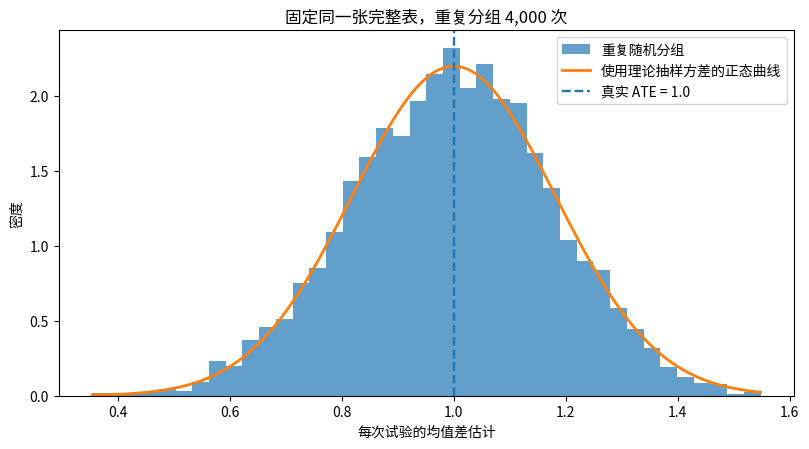

In [14]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.hist(repeated["estimate"], bins=40, density=True, alpha=0.7, label="重复随机分组")
x_grid = np.linspace(repeated["estimate"].min(), repeated["estimate"].max(), 300)
true_sd = np.sqrt(true_variance)
normal_density = np.exp(-0.5 * ((x_grid - true_ate) / true_sd) ** 2) / (np.sqrt(2 * np.pi) * true_sd)
ax.plot(x_grid, normal_density, linewidth=2, label="使用理论抽样方差的正态曲线")
ax.axvline(true_ate, linestyle="--", linewidth=1.7, label=f"真实 ATE = {true_ate:.1f}")
ax.set_xlabel("每次试验的均值差估计")
ax.set_ylabel("密度")
ax.set_title(f"固定同一张完整表，重复分组 {N_REPEATS:,} 次")
ax.legend()
fig.tight_layout()
plt.show()

这里 `estimate` 的分布围绕 1 波动。理论方差、重复试验中的样本方差和平均方差估计应当相近；后二者由有限次模拟计算，不要求逐位相等。

表中的两个 Monte Carlo 标准误分别描述“模拟偏差”和“覆盖率”这两个汇总数的计算精度。它们不是某一次试验的效应标准误。比如覆盖率在 0.95 左右时，4,000 次重复对应的 MC 标准误约为 0.0034，看到几个千分点的差异并不奇怪。

再把最开始的 60 个区间画出来。保留产生顺序，不按是否覆盖挑选试验。

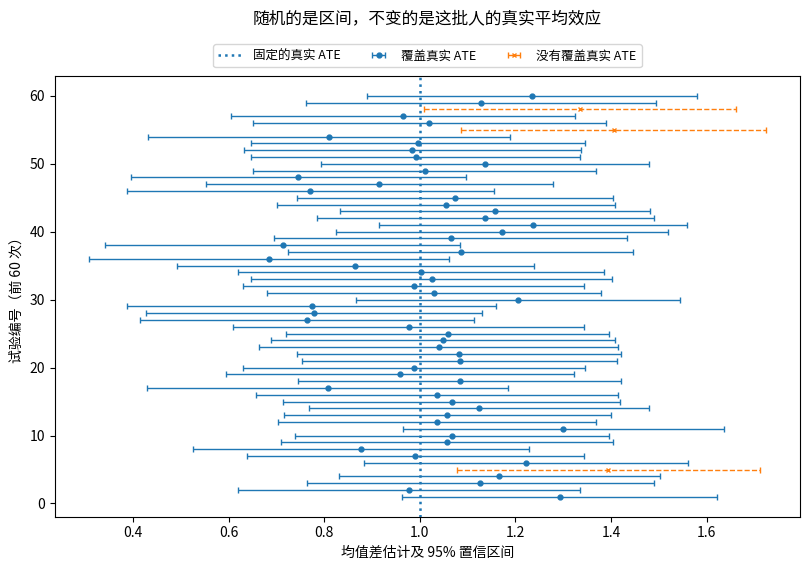

全部 4,000 次的覆盖率：94.85%；前 60 次仅用于展示。


In [15]:
shown = repeated.iloc[:60]
fig, ax = plt.subplots(figsize=(8.2, 5.8))
for covered, marker, line_style, label in [
    (True, "o", "-", "覆盖真实 ATE"),
    (False, "x", "--", "没有覆盖真实 ATE"),
]:
    mask = shown["covered"].to_numpy() == covered
    positions = np.flatnonzero(mask) + 1
    ax.errorbar(shown.loc[mask, "estimate"], positions,
                xerr=Z_CRIT * shown.loc[mask, "se"], fmt=marker,
                markersize=3.5, elinewidth=1, capsize=2, linestyle="none", label=label)
    # errorbar 的区间线单独设置实线/虚线，保留默认配色。
    for collection in ax.containers[-1].lines[2]:
        collection.set_linestyle(line_style)
ax.axvline(true_ate, linestyle=":", linewidth=1.8, label="固定的真实 ATE")
ax.set_xlabel("均值差估计及 95% 置信区间")
ax.set_ylabel("试验编号（前 60 次）")
ax.set_title("随机的是区间，不变的是这批人的真实平均效应", pad=38)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=3, fontsize=9)
fig.tight_layout()
plt.show()
print(f"全部 {N_REPEATS:,} 次的覆盖率：{coverage:.2%}；前 60 次仅用于展示。")

## 进一步分析

### 1. 每人的效应不一样，区间会怎样？

刚才每个人的效应都是 1，所以 $S_\tau^2=0$。下面按原书第 4.5.1 节再做两种变化：保持整列 $Y(1)$ 不动，只把 $Y(0)$ 改为反向排序或随机重排。

这样两列各自的数值集合都没变，潜在结局的边际均值、方差和平均处理效应都没变；改变的是同一个人的 $Y_i(0)$ 与 $Y_i(1)$ 怎样配对。**这是比较不同的假想完整表，不是对现实数据做排序调整。**

把三种配对关系画出来，再逐种重复随机试验。随机重排在一张有限表上不保证相关系数恰好为零，因此这里称它为“随机配对”，不直接称“独立”。

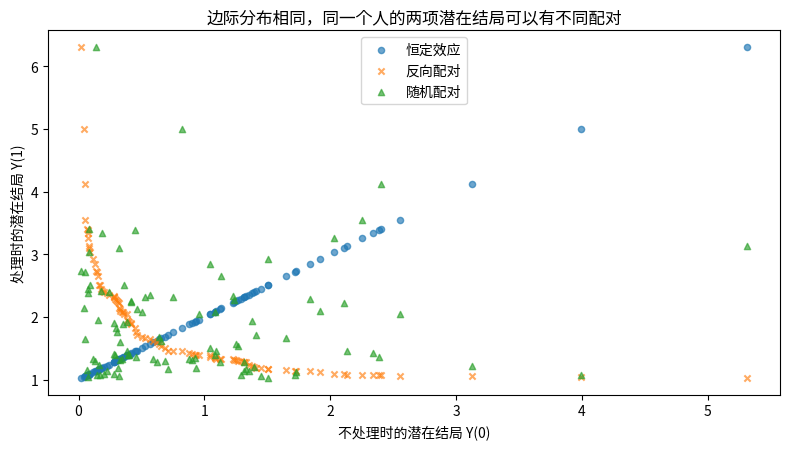

In [16]:
rng_pairing = np.random.default_rng(SEED_PAIRING)
paired_y0 = {
    "恒定效应": y0.copy(),
    "反向配对": y0[::-1].copy(),
    "随机配对": rng_pairing.permutation(y0),
}
fig, ax = plt.subplots(figsize=(8.0, 4.6))
for (name, y0_version), marker in zip(paired_y0.items(), ["o", "x", "^"]):
    ax.scatter(y0_version, y1, s=20, alpha=0.65, marker=marker, label=name)
    np.testing.assert_allclose(np.sort(y0_version), np.sort(y0))
    np.testing.assert_allclose((y1 - y0_version).mean(), true_ate)
ax.set_xlabel("不处理时的潜在结局 Y(0)")
ax.set_ylabel("处理时的潜在结局 Y(1)")
ax.set_title("边际分布相同，同一个人的两项潜在结局可以有不同配对")
ax.legend()
fig.tight_layout()
plt.show()

从完整表计算的理论量（现实中不能完整观察）：


,潜在结局相关,个体效应方差,理论抽样方差,理论平均方差估计
配对方式,,,,
恒定效应,1.0000,0.0000,0.0330,0.033
反向配对,-0.6514,2.6130,0.0068,0.033
随机配对,0.0079,1.5698,0.0173,0.033


从重复试验得到的结果：


,模拟抽样方差,平均方差估计,95% 覆盖率
配对方式,,,
恒定效应,0.0321,0.0330,0.9485
反向配对,0.0069,0.0329,1.0000
随机配对,0.0173,0.0329,0.9932


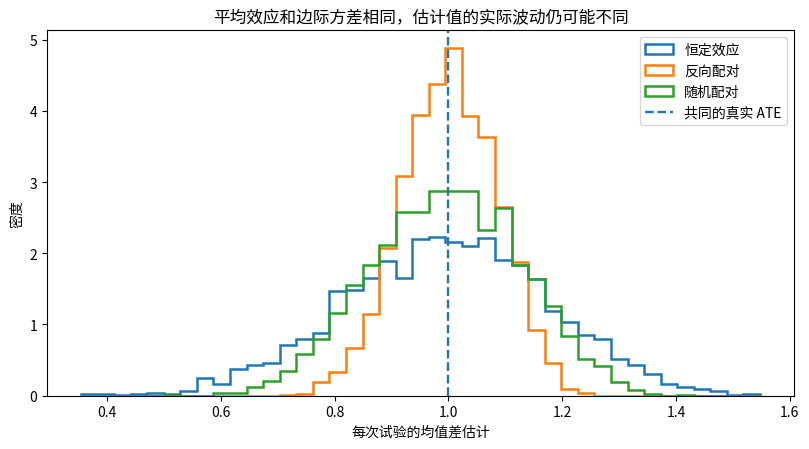

In [17]:
pairing_runs = {}
pairing_records = []
for name, y0_version in paired_y0.items():
    run = repeated if name == "恒定效应" else simulate_cre(
        y0_version, y1, n1, N_REPEATS, SEED_REPEAT
    )
    pairing_runs[name] = run
    effect_variance = np.var(y1 - y0_version, ddof=1)
    marginal_part = np.var(y1, ddof=1) / n1 + np.var(y0_version, ddof=1) / n0
    pairing_records.append({
        "配对方式": name,
        "潜在结局相关": np.corrcoef(y0_version, y1)[0, 1],
        "个体效应方差": effect_variance,
        "理论抽样方差": marginal_part - effect_variance / n,
        "模拟抽样方差": run["estimate"].var(ddof=1),
        "平均方差估计": run["variance"].mean(),
        "理论平均方差估计": marginal_part,
        "95% 覆盖率": run["covered"].mean(),
    })
pairing_summary = pd.DataFrame(pairing_records).set_index("配对方式")
print("从完整表计算的理论量（现实中不能完整观察）：")
display(pairing_summary[["潜在结局相关", "个体效应方差", "理论抽样方差", "理论平均方差估计"]].round(4))
print("从重复试验得到的结果：")
display(pairing_summary[["模拟抽样方差", "平均方差估计", "95% 覆盖率"]].round(4))

fig, ax = plt.subplots(figsize=(8.2, 4.6))
all_estimates = np.concatenate([run["estimate"].to_numpy() for run in pairing_runs.values()])
bins = np.linspace(all_estimates.min(), all_estimates.max(), 42)
for name, run in pairing_runs.items():
    ax.hist(run["estimate"], bins=bins, density=True, histtype="step", linewidth=1.8, label=name)
ax.axvline(true_ate, linestyle="--", linewidth=1.7, label="共同的真实 ATE")
ax.set_xlabel("每次试验的均值差估计")
ax.set_ylabel("密度")
ax.set_title("平均效应和边际方差相同，估计值的实际波动仍可能不同")
ax.legend()
fig.tight_layout()
plt.show()

默认结果中，恒定效应的理论抽样方差约为 0.0330，反向配对约为 0.0068；三种情形的平均方差估计却都在 0.033 附近。

三种情形下，理论平均方差估计一样，因为它只取决于两列各自的方差。但真实抽样方差还要减去 $S_\tau^2/n$。因此在这个特意保持边际分布不变的比较中，异质性越大，真实抽样方差越小，而 Neyman 区间可能覆盖得更多。[1，第 4.5.1 节]

不能把这句话推广为“效应越不一致，估计就越精确”。如果改变效应的同时也改变了 $S_1^2$ 或 $S_0^2$，方差公式中的其他项也会变化。这里是在固定其他项的条件下观察最后一项。

### 2. 分层随机化：先按基础分层，再在层内抽签

完全随机分配只保证总体上不偏向某类人，并不保证一次分组中各类人的比例相同。可以在分配前按已经测量的基础变量分层，再在每层内独立做 CRE。这就是分层随机试验（SRE）。[1，第 5.1 节]

下面另外构造 4 层、每层 60 人的数据。$X$ 是处理前就已知的层标签；它不是不可观察的 $Y(0)$。各层的基础结局不同，每人的处理效应暂时仍固定为 1。每层分别抽出一半接受处理，看看是否比整体抽一半更精确。

层 $h$ 的均值差记为 $\widehat\tau_h$，人数为 $n_h$。目标仍是全部人的平均效应，计算时使用固定的人群权重 $w_h=n_h/n$：

$$
\widehat\tau_S=\sum_h w_h\widehat\tau_h,\qquad
\widehat V_S=\sum_h w_h^2\left(\frac{s_{1h}^2}{n_{1h}}+\frac{s_{0h}^2}{n_{0h}}\right).
$$

方差中的权重要平方，因为各层分配相互独立，随机量乘以 $w_h$ 后，方差乘以 $w_h^2$。每层每组至少要有 2 人才能计算这里的组内方差。[1，第 5.3.1 节]

In [18]:
# 自行构造的分层试验；使用的设计和估计方法来自参考资料 [1] 第 5 章。
rng_block_data = np.random.default_rng(SEED_BLOCK)
block = np.repeat(np.arange(4), 60)
block_indices = [np.flatnonzero(block == h) for h in np.unique(block)]
block_y0 = 2.0 * block + rng_block_data.exponential(scale=1.0, size=len(block))
block_y1 = block_y0 + 1.0
block_target = float(np.mean(block_y1 - block_y0))
block_weights = np.array([len(idx) / len(block) for idx in block_indices])
block_templates = [np.r_[np.ones(30, dtype=int), np.zeros(30, dtype=int)] for _ in block_indices]

rng_block_assign = np.random.default_rng(SEED_BLOCK + 1)
t_block = np.zeros(len(block), dtype=int)
for idx, template in zip(block_indices, block_templates):
    t_block[idx] = rng_block_assign.permutation(template)
y_block = np.where(t_block == 1, block_y1, block_y0)
block_observed = pd.DataFrame({"X": block, "T": t_block, "Y": y_block})
display(block_observed.groupby(["X", "T"])["Y"].agg(人数="size", 均值="mean").round(3))

人数     均值
X T           
0 0  30  0.856
  1  30  1.917
1 0  30  2.951
  1  30  3.937
2 0  30  5.065
  1  30  5.979
3 0  30  7.200
  1  30  8.189

In [19]:
def stratified_estimate(t: np.ndarray, y: np.ndarray, x: np.ndarray) -> tuple[float, float]:
    """按全部受试者的层比例，加权层内均值差及其方差。"""
    checked_groups(t, y)
    t, y, x = np.asarray(t), np.asarray(y, dtype=float), np.asarray(x)
    if x.ndim != 1 or len(x) != len(t) or pd.isna(x).any():
        raise ValueError("X 必须是一维、等长且无缺失的层标签。")
    estimate, variance = 0.0, 0.0
    for h in np.unique(x):
        mask = x == h
        weight = float(mask.mean())
        tau_h, var_h = neyman_estimate(t[mask], y[mask])
        estimate += weight * tau_h
        variance += weight ** 2 * var_h
    return estimate, variance


block_est, block_var = stratified_estimate(t_block, y_block, block)
print(f"本次分层估计：{block_est:.4f}，标准误：{np.sqrt(block_var):.4f}")
print(f"95% 区间：[{block_est - Z_CRIT * np.sqrt(block_var):.4f}, "
      f"{block_est + Z_CRIT * np.sqrt(block_var):.4f}]")

# 每层处理比例相同的本例，两种点估计恰好相同；方差计算仍要尊重分层设计。
np.testing.assert_allclose(block_est, difference_in_means(t_block, y_block))

本次分层估计：0.9873，标准误：0.1299
95% 区间：[0.7327, 1.2418]


,平均估计,估计值的标准差,平均区间宽度,95% 覆盖率
整体完全随机分配,1.0041,0.3286,1.2923,0.9515
层内分别随机分配,0.9974,0.1265,0.5050,0.9480


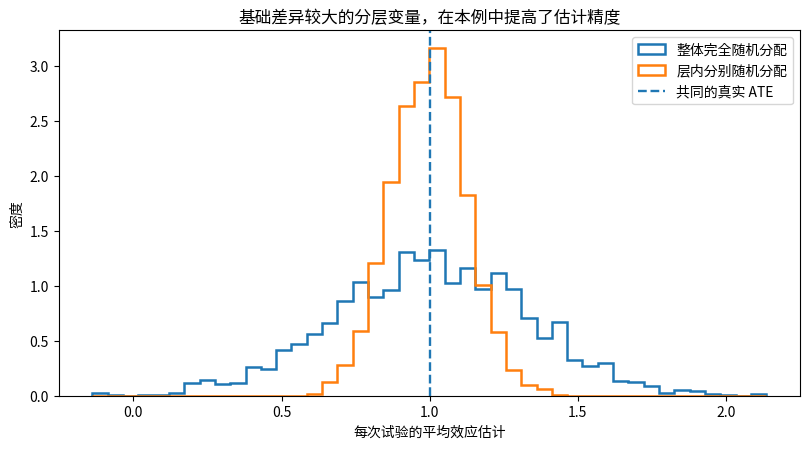

In [20]:
block_repeats = 2000
rng_block_repeat = np.random.default_rng(SEED_BLOCK + 2)
block_results = np.empty((block_repeats, 2))
for b in range(block_repeats):
    t_new = np.zeros(len(block), dtype=int)
    for idx, template in zip(block_indices, block_templates):
        t_new[idx] = rng_block_repeat.permutation(template)
    y_new = np.where(t_new == 1, block_y1, block_y0)
    block_results[b] = stratified_estimate(t_new, y_new, block)

sre_estimates, sre_variances = block_results[:, 0], block_results[:, 1]
cre_block = simulate_cre(block_y0, block_y1, len(block) // 2, block_repeats, SEED_BLOCK + 3)
sre_covered = np.abs(sre_estimates - block_target) <= Z_CRIT * np.sqrt(sre_variances)
block_comparison = pd.DataFrame({
    "平均估计": [cre_block["estimate"].mean(), sre_estimates.mean()],
    "估计值的标准差": [cre_block["estimate"].std(ddof=1), sre_estimates.std(ddof=1)],
    "平均区间宽度": [(cre_block["upper"] - cre_block["lower"]).mean(),
                  np.mean(2 * Z_CRIT * np.sqrt(sre_variances))],
    "95% 覆盖率": [cre_block["covered"].mean(), sre_covered.mean()],
}, index=["整体完全随机分配", "层内分别随机分配"])
display(block_comparison.round(4))

fig, ax = plt.subplots(figsize=(8.2, 4.6))
values = np.r_[cre_block["estimate"], sre_estimates]
bins = np.linspace(values.min(), values.max(), 45)
ax.hist(cre_block["estimate"], bins=bins, density=True, histtype="step", linewidth=1.8,
        label="整体完全随机分配")
ax.hist(sre_estimates, bins=bins, density=True, histtype="step", linewidth=1.8,
        label="层内分别随机分配")
ax.axvline(block_target, linestyle="--", linewidth=1.7, label="共同的真实 ATE")
ax.set_xlabel("每次试验的平均效应估计")
ax.set_ylabel("密度")
ax.set_title("基础差异较大的分层变量，在本例中提高了估计精度")
ax.legend()
fig.tight_layout()
plt.show()

这两种设计用的是同一批人和同一张完整表，处理总人数也相同。差别在于，整体随机分组允许各层人数比例偶然失衡，而层内随机分组固定了这种比例。默认模拟中，分层后分布更集中，区间也更窄。

这里没有把所有变量都拿来分层。分层变量应在处理前确定；变量与结局的关系以及每层人数，都会影响这种设计的实际收益。上面的图只反映本例，不表示任意分层都保证改善。

还要注意检验的分配机制：如果对分层试验做 FRT，应保持观察结局不变，**只在每层内部打乱处理标签**，不能直接调用前面那个全局打乱的 `fisher_mc`。[1，第 5.2.1 节] 可以在同一份观察数据上算一次：

In [21]:
rng_sre_frt = np.random.default_rng(SEED_BLOCK + 4)
sre_perm_stats = np.empty(N_PERMUTATIONS)
for b in range(N_PERMUTATIONS):
    perm_t = t_block.copy()
    for idx in block_indices:
        perm_t[idx] = rng_sre_frt.permutation(t_block[idx])
    # Y 不变；每层处理人数也不变。这里只计算检验所用的点统计量。
    sre_perm_stats[b] = sum(
        weight * difference_in_means(perm_t[idx], y_block[idx])
        for weight, idx in zip(block_weights, block_indices)
    )
k_sre = int(np.sum(np.abs(sre_perm_stats) >= abs(block_est) - 1e-12))
p_sre = (k_sre + 1) / (N_PERMUTATIONS + 1)
print(f"层内随机化检验：双侧 p = {p_sre:.6f}（{k_sre} 次至少同样极端）")
assert all(perm_t[idx].sum() == t_block[idx].sum() for idx in block_indices)

层内随机化检验：双侧 p = 0.000200（0 次至少同样极端）


## 结果分析

8 人案例中，均值差是 8.5 分，但检查全部 70 种分配以后，双侧 p 值略大于 0.05。点估计为正，不等于证据足以排除随机分组造成的差异。

100 人模拟中，重复随机分组让我们直接检查了均值差的抽样分布和区间覆盖率。改变两项潜在结局的配对后，真实方差随之改变，但观察数据能够估计的方差部分没有改变。这解释了 Neyman 方差为什么会保守。

分层部分又说明，随机化不是统一的一次“打乱标签”。完全随机与层内随机是不同设计，点估计、方差和随机化检验都应与实际分配规则相匹配。

参考资料 [2] 第 2.1 节从独立同分布样本出发，讨论更大总体的 $E[Y(1)-Y(0)]$；本篇按 [1] 固定完整表，讨论 $\operatorname{ATE}_n$。实际标准误都出现两组样本方差除以人数的形式，但背后的重复机制不同：不能因此从 [2] 的总体公式直接删去本篇的 $-S_\tau^2/n$，也不能把试验内的随机分配当作从外部总体随机抽样。[1，第 4.2 节；2，第 2.1 节]

## 练习

### 1. 精确 p 值在零假设下会怎样分布？

假设 8 人案例确实满足人人无效。轮流把 70 种分组各看成一次实际试验，分别计算其精确 p 值，再检查在 0.01、0.05、0.10、0.20 水平下，拒绝的比例是多少。

这是 [1] 式（3.3）的数值检查：有限样本有效性要求拒绝概率不超过检验水平，不要求总是恰好相等。下面直接用前面已经枚举的分布计算。

In [22]:
exact_abs = np.abs(exact_stats)
# 每个统计量依次当作观察值，计算它在同一个零假设分布中的双侧 p 值。
all_exact_p = np.array([
    np.mean(exact_abs >= observed_abs - 1e-12)
    for observed_abs in exact_abs
])
levels = np.array([0.01, 0.05, 0.10, 0.20])
rejection_rates = np.array([np.mean(all_exact_p <= level + 1e-12) for level in levels])
display(pd.DataFrame({
    "检验水平": levels,
    "零假设下精确拒绝比例": rejection_rates,
    "是否不超过检验水平": rejection_rates <= levels + 1e-12,
}).round(4))
assert np.all(rejection_rates <= levels + 1e-12)

,检验水平,零假设下精确拒绝比例,是否不超过检验水平
0,0.01,0.0000,True
1,0.05,0.0000,True
2,0.10,0.0571,True
3,0.20,0.2000,True


这组成绩在 0.05 水平下的拒绝比例甚至为 0，因为它能达到的最小双侧精确 p 值就是 $4/70$。由于 p 值是离散的，拒绝比例可能小于给定水平。这个结论来自完整枚举，不含 Monte Carlo 误差。它以正确的 CRE 设计和尖锐零假设为前提，不能直接套用到自行选择是否接受处理的观察性数据。

### 2. 每层处理比例不同，还能把所有人直接合起来算吗？

保留分层模拟的完整表，将四层的处理人数分别改成 12、24、36、48（每层仍为 60 人）。处理总人数还是 120，但基础结局较高的层接受处理更多。比较整体均值差与按人群层比例加权的估计。

这个练习由 [1] 第 5.1–5.3 节的分层设计展开。每层内部依然随机，但整体处理状态不再与层标签独立。下面既算两种估计在该设计下的理论期望，也实际重复分配。

In [23]:
unequal_counts = np.array([12, 24, 36, 48])
unequal_templates = [
    np.r_[np.ones(int(count), dtype=int), np.zeros(len(idx) - int(count), dtype=int)]
    for count, idx in zip(unequal_counts, block_indices)
]
stratum_means1 = np.array([block_y1[idx].mean() for idx in block_indices])
stratum_means0 = np.array([block_y0[idx].mean() for idx in block_indices])
control_counts = np.array([len(idx) for idx in block_indices]) - unequal_counts
expected_pooled = (np.dot(unequal_counts / unequal_counts.sum(), stratum_means1)
                   - np.dot(control_counts / control_counts.sum(), stratum_means0))
expected_weighted = float(np.dot(block_weights, stratum_means1 - stratum_means0))

rng_exercise = np.random.default_rng(SEED_BLOCK + 5)
exercise_estimates = np.empty((1000, 2))
for b in range(len(exercise_estimates)):
    t_new = np.zeros(len(block), dtype=int)
    for idx, template in zip(block_indices, unequal_templates):
        t_new[idx] = rng_exercise.permutation(template)
    y_new = np.where(t_new == 1, block_y1, block_y0)
    exercise_estimates[b, 0] = difference_in_means(t_new, y_new)
    exercise_estimates[b, 1] = stratified_estimate(t_new, y_new, block)[0]

display(pd.DataFrame({
    "理论期望": [expected_pooled, expected_weighted],
    "1000 次估计的平均值": exercise_estimates.mean(axis=0),
    "相对真实 ATE 的理论偏差": [expected_pooled - block_target, expected_weighted - block_target],
}, index=["直接合并的均值差", "按人群层比例加权"]).round(4))
np.testing.assert_allclose(expected_weighted, block_target)

,理论期望,1000 次估计的平均值,相对真实 ATE 的理论偏差
直接合并的均值差,3.1003,3.1038,2.1003
按人群层比例加权,1.0000,1.0041,-0.0000


直接合并时，处理组更多来自基础结局较高的层，对照组更多来自基础较低的层，两边使用的人群权重不同。因此，尽管层内是随机试验，整体均值差也不再无偏估计全体的 ATE。

按 $n_h/n$ 加权各层效应则使用同一个目标人群构成，仍能无偏估计这个目标。并不是“随机试验失效了”，而是分析没有使用与设计相符的比较。

## 总结

完全随机试验为两组均值差提供了明确的推断依据，但一次随机分配仍有误差。Fisher 检验在尖锐零假设下补全潜在结局，再按原设计检查观察统计量有多极端；Neyman 推断则研究平均效应估计的波动，并构造大样本置信区间。

实现时最容易混淆的两行代码是：FRT 固定 `y` 再改变 `t`；重复真实试验的模拟则固定 `y0, y1`，改变 `t` 后重新生成 `y`。分组方式改变，重放的随机化机制也要跟着改变。

接下来转向观察性研究之前，还需要说明：没有随机分组时，哪些变量应该调整、调整以后为何可能得到因果解释。这是下一篇因果图与识别假设的内容。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. arXiv:2305.18793v2，2023-10-03。对应上传文件 `因果推断.pdf`。本篇主要使用第 3.1–3.3 节（正文第 25–31 页，CRE 与 FRT）、习题 3.3（第 41 页，Monte Carlo p 值加一修正）、第 4.1–4.3 节（第 43–48 页，有限总体方差与置信区间）、第 4.5.1 节（第 50–51 页，保持边际分布不变的模拟），以及第 5.1–5.3 节（第 59–70 页，分层随机试验）。正文页码与 PDF 页码不同；例如正文第 25 页在上传 PDF 第 51 页。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. Version 0.1.2，2026-05-03。对应上传文件 `CausalML_book_2022.pdf`，以扉页版本为准。参考第 2.1 节（正文第 44–50 页，潜在结局、随机分配、两组均值推断），特别是第 49–50 页的独立同分布样本视角。

8 人成绩表、分层数据和练习中的具体数值均为教学构造；100 人指数分布模拟及重新配对实验沿用 [1] 第 4.5.1 节的设计，改用 Python 随机数并设置固定种子。图表全部由本篇代码生成，不是书中截图或预先写入的静态结论。